# Exploring `notion_export.json`

A short exploratory pass over `notion_export.json` to understand **what the
file actually is** before building anything on top of it: where it came
from, what tables it contains, how they relate, and what basic patterns
show up in each one.


In [7]:
import json
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

with open(r"../docs/notion_export.json", encoding="utf-8") as f:
    raw = json.load(f)

print("top-level keys:", list(raw.keys()))
for key, value in raw.items():
    if isinstance(value, list):
        print(f"  {key}: list of {len(value)} records")
    elif isinstance(value, dict):
        print(f"  {key}: dict with keys {list(value.keys())}")


top-level keys: ['_meta', 'locations', 'calendar', 'contacts', 'projects']
  _meta: dict with keys ['source', 'website', 'author', 'generated_at', 'encoding', 'schema_version', 'export_filter', 'usage', 'databases', 'quality']
  locations: list of 157 records
  calendar: list of 795 records
  contacts: list of 515 records
  projects: list of 889 records


## 1. What is this file?

The `_meta` block answers that directly -- it's a filtered **Notion export
for the Ars Electronica Festival 2026 ("Negotiating Humanity")**, generated
specifically for this hackathon (`export_filter: public_for_hackathon = true`).
It ships its own data dictionary (`_meta.databases`) and even usage notes
for exactly the kind of join/visibility questions an EDA would otherwise
have to reverse-engineer.


In [2]:
meta = raw["_meta"]
print("source: ", meta["source"])
print("website:", meta["website"])
print("generated_at:", meta["generated_at"])
print("schema_version:", meta["schema_version"])
print("export_filter:", meta["export_filter"])
print()
print("Databases in this export:")
for name, info in meta["databases"].items():
    print(f"  - {name:10s} {info['count']:4d} records -- {info['description']}")


source:  Ars Electronica Festival 2026
website: https://ars.electronica.art/negotiatinghumanity
generated_at: 2026-09-07T09:11:54.863Z
schema_version: 2.0
export_filter: public_for_hackathon = true

Databases in this export:
  - locations   157 records -- Event venues, hierarchically organised as building, floor and room.
  - calendar    795 records -- Event time slots. Leading relation for concrete dates: calendar.Linked Projects.
  - contacts    515 records -- Artists, speakers, institutions and project partners.
  - projects    889 records -- Central database of all projects, collections and events of the festival.


In [3]:
# The export's own notes on how the tables join and what "visible" means.
print("How to join tables (from _meta.usage):")
print(" ", meta["usage"]["join_key"])
print()
print("Which relation is authoritative for dates:")
print(" ", meta["usage"]["leading_calendar_relation"])
print()
print("How visibility was filtered:")
print(" ", meta["usage"]["status_rules"])


How to join tables (from _meta.usage):
  canonical_id – überall 32-stelliger Hex-Wert. Alle Linked-* Felder enthalten canonical_id-Werte.

Which relation is authoritative for dates:
  calendar ist führend für konkrete Termine. Timetable-Apps lesen calendar.Linked Projects bzw. calendar.project_ref. projects.Times ist nur eine Textzusammenfassung, projects.Linked Calendar ist nicht zuverlässig auflösbar.

How visibility was filtered:
  Sichtbarkeit wird ausschließlich über die Tabelle STATUS_RULES im Export-Node gesteuert. Nur Status Web = done gilt als final und sichtbar, alles andere wird ausgeblendet. Jeder Datensatz trägt status_web und visibility_rule zur Nachvollziehbarkeit.


In [4]:
# Export quality / referential-integrity notes -- worth knowing before trusting any join.
quality = meta["quality"]
print("Calendar slots with no linked project:", quality["calendar_without_project"])
print()
print("Relations stripped because their target wasn't public (would otherwise dangle):")
for k, v in quality["referential_integrity"].items():
    print(f"  {k}: {v}")


Calendar slots with no linked project: 0

Relations stripped because their target wasn't public (would otherwise dangle):
  calendar_project_ref_stripped: 1
  projects_linked_contacts_stripped: 10
  contacts_linked_projects_stripped: 3
  projects_linked_parent_stripped: 13
  projects_linked_child_stripped: 8
  locations_linked_projects_stripped: 12


## 2. The four tables, at a glance

Everything below is a normalized Notion database: `locations` (venues),
`calendar` (concrete time slots), `contacts` (people/orgs), and `projects`
(the festival's actual content -- exhibitions, performances, talks...).
Every record carries a `canonical_id` (the join key), a `status_web` /
`visibility_rule` pair (all `done` / `public` here, since this export is
already filtered down to what's visible), and `Linked *` fields pointing at
other tables' `canonical_id`s.


In [5]:
locations = pd.DataFrame(raw["locations"])
calendar = pd.DataFrame(raw["calendar"])
contacts = pd.DataFrame(raw["contacts"])
projects = pd.DataFrame(raw["projects"])

overview = pd.DataFrame(
    {
        "rows": [len(locations), len(calendar), len(contacts), len(projects)],
        "columns": [locations.shape[1], calendar.shape[1], contacts.shape[1], projects.shape[1]],
    },
    index=["locations", "calendar", "contacts", "projects"],
)
overview

,rows,columns
locations,157,32
calendar,795,25
contacts,515,20
projects,889,45


In [6]:
# quick missing-value snapshot per table (share of empty/null cells per column, top offenders only)
for name, df in [("locations", locations), ("calendar", calendar), ("contacts", contacts), ("projects", projects)]:
    missing = df.isna().mean().sort_values(ascending=False)
    missing = missing[missing > 0.3]
    print(f"{name}: {len(missing)} column(s) >30% empty")
    if len(missing):
        print(missing.round(2).to_string())
    print()


locations: 11 column(s) >30% empty
Services              0.96
Additional Info EN    0.90
Additional Info DE    0.90
LinkedIn              0.90
Linked Child          0.80
Facebook              0.80
Instagram             0.79
Description EN        0.75
Description DE        0.74
Website               0.71
Linked Parent         0.31

calendar: 5 column(s) >30% empty
Event before           1.00
Event afterwards       1.00
Weekday                1.00
Recommended Arrival    0.94
Registration URL       0.64

contacts: 4 column(s) >30% empty
Facebook     0.85
Name DE      0.78
LinkedIn     0.66
Instagram    0.51

projects: 26 column(s) >30% empty
Recommended Arrival    0.97
LinkedIn               0.91
Facebook               0.91
Video URL              0.89
Funding Line           0.89
Additional Info DE     0.89
Max Participants       0.88
Subtitle DE            0.87
Additional Info EN     0.87
Registration URLs      0.86
Name DE                0.84
Website Secondary      0.83
Linked Child     

## 3. Locations -- where the festival happens

Venues are structured hierarchically (`Building` → `Floor` / `Outdoor` →
`Room`, via `Linked Parent`/`Linked Child`) and grouped into festival
**areas**. Almost all carry real coordinates.


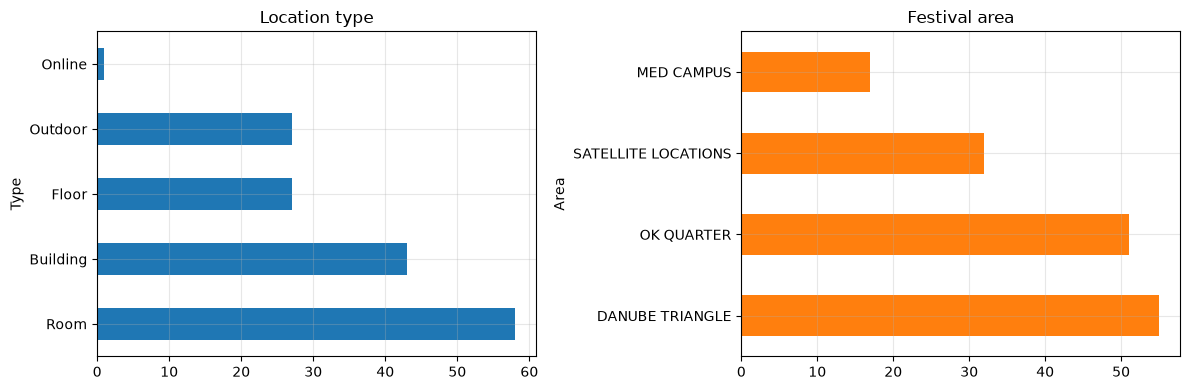

152 / 157 locations have verified coordinates


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
locations["Type"].value_counts().plot(kind="barh", ax=axes[0], title="Location type")
locations["Area"].value_counts().plot(kind="barh", ax=axes[1], title="Festival area", color="tab:orange")
plt.tight_layout()
plt.show()

print(f"{locations['coordinates_ok'].eq(True).sum()} / {len(locations)} locations have verified coordinates")

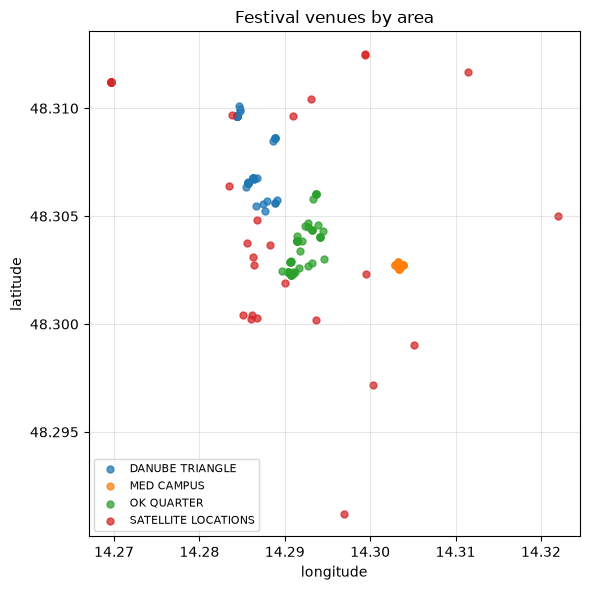

In [8]:
geo = locations.dropna(subset=["Latitude", "Longitude"])
fig, ax = plt.subplots(figsize=(6, 6))
for area, sub in geo.groupby("Area"):
    ax.scatter(sub["Longitude"], sub["Latitude"], label=area, s=25, alpha=0.75)
ax.set_title("Festival venues by area")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Calendar -- when things happen

`calendar` is explicitly called out as the **authoritative source for
concrete dates** (`projects.Times` is just a text summary). Each row is one
bookable time slot for one project.


Festival runs 2026-09-08 to 2026-09-13 (6 days, 795 time slots)


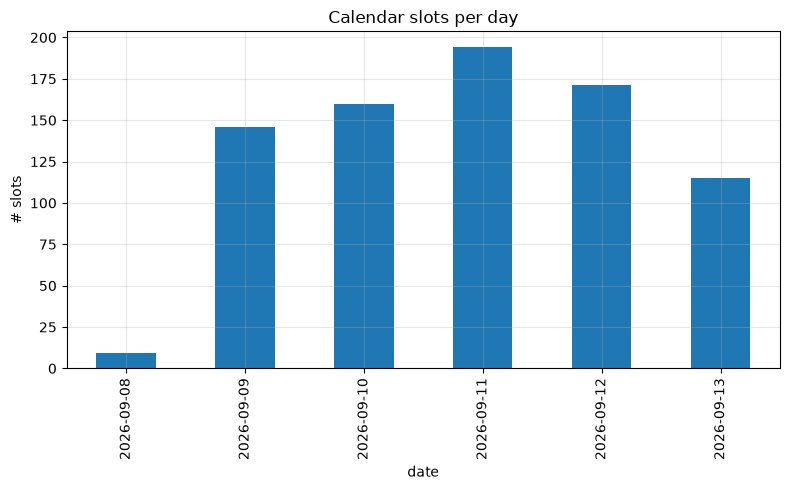

In [9]:
def parse_date(time_str):
    months = {"Januar":1,"Februar":2,"März":3,"April":4,"Mai":5,"Juni":6,"Juli":7,
              "August":8,"September":9,"Oktober":10,"November":11,"Dezember":12}
    if not isinstance(time_str, str):
        return pd.NaT
    m = re.match(r"(\d+)\.\s+(\w+)\s+(\d{4})", time_str)
    if not m:
        return pd.NaT
    day, month, year = m.groups()
    return pd.Timestamp(year=int(year), month=months.get(month, 1), day=int(day))

calendar["date"] = calendar["Time"].apply(parse_date)
date_range = calendar["date"].dropna()
print(f"Festival runs {date_range.min().date()} to {date_range.max().date()} "
      f"({date_range.nunique()} days, {len(calendar)} time slots)")

daily_counts = date_range.dt.date.value_counts().sort_index()
daily_counts.index = daily_counts.index.astype(str)
daily_counts.plot(kind="bar", title="Calendar slots per day")
plt.ylabel("# slots")
plt.tight_layout()
plt.show()

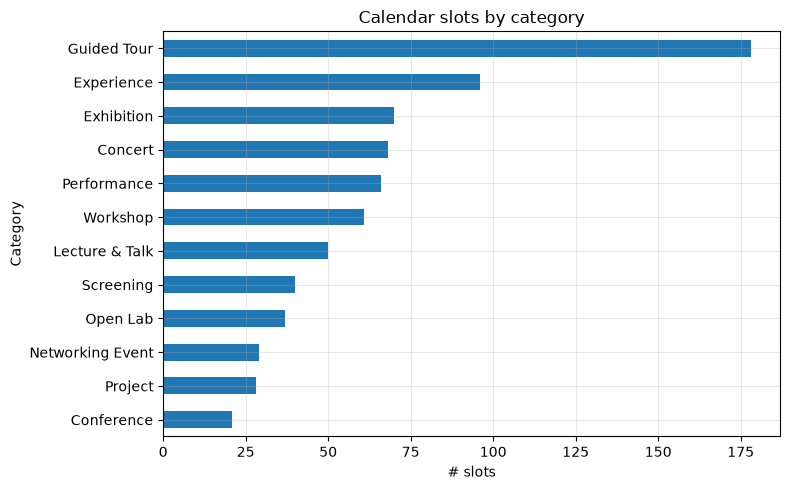

Language mix (top 6):
Language
EN                 341
DE,EN              161
DE                  87
nonverbal           71
DE,EN,nonverbal     11
nonverbal,other      6
Name: count, dtype: int64

Curated 'Highlight' slots: 154 / 795


In [10]:
calendar["Category"].value_counts().head(12).plot(
    kind="barh", title="Calendar slots by category")
plt.gca().invert_yaxis()
plt.xlabel("# slots")
plt.tight_layout()
plt.show()

print("Language mix (top 6):")
print(calendar["Language"].value_counts().head(6))
print()
print("Curated 'Highlight' slots:", (calendar["Highlight"] == "Yes").sum(), "/", len(calendar))

## 5. Contacts -- who's involved

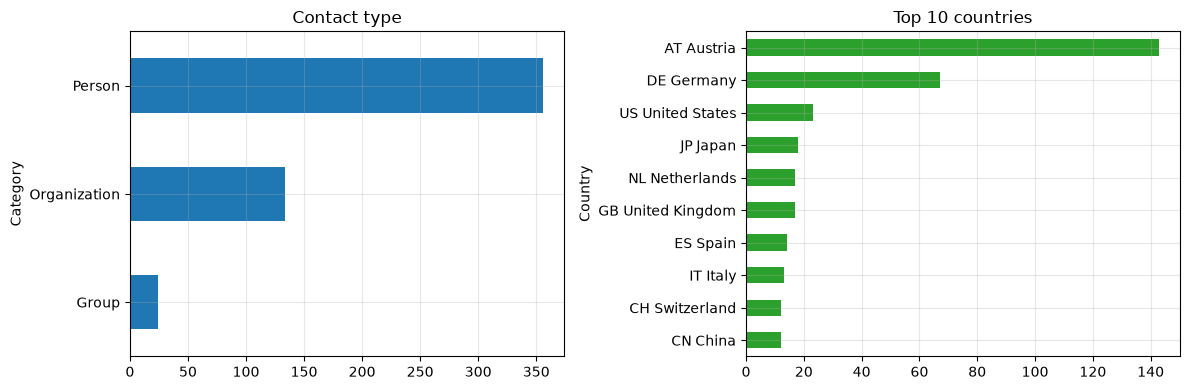

Contacts span 108 countries -- this is an international festival.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
contacts["Category"].value_counts().plot(kind="barh", ax=axes[0], title="Contact type")
contacts["Country"].value_counts().head(10).plot(
    kind="barh", ax=axes[1], title="Top 10 countries", color="tab:green")
axes[0].invert_yaxis()
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

n_countries = contacts["Country"].nunique()
print(f"Contacts span {n_countries} countries -- this is an international festival.")

## 6. Projects -- the actual content

`projects` is the festival's central table: exhibitions, performances,
talks, workshops, and higher-level "Collections" that group them. This is
what `calendar` slots and `contacts` ultimately attach to.


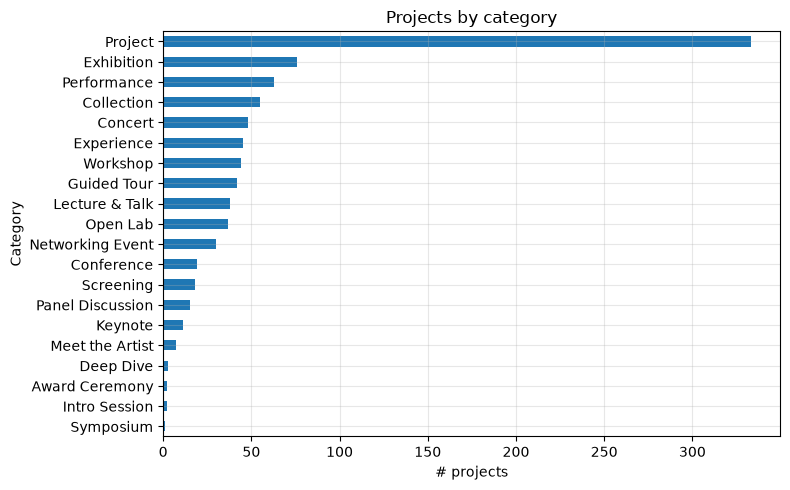

Curatorial highlights: 84 / 889
Projects with at least one calendar slot: 383 / 889
Projects with at least one linked contact: 386 / 889


In [12]:
projects["Category"].value_counts().plot(
    kind="barh", title="Projects by category")
plt.gca().invert_yaxis()
plt.xlabel("# projects")
plt.tight_layout()
plt.show()

print("Curatorial highlights:", (projects["Curatorial Highlight"] == "Yes").sum(), "/", len(projects))
print("Projects with at least one calendar slot:", projects["calendar_ids"].apply(bool).sum(), "/", len(projects))
print("Projects with at least one linked contact:", projects["Linked Contacts"].apply(bool).sum(), "/", len(projects))

## 7. How the tables connect

Every `Linked *` field is a list of `canonical_id`s pointing into another
table. `projects.calendar_ids` is called out as the *recommended* backward
link from a project to its slots (derived straight from the exported
calendar, so it's guaranteed resolvable) -- unlike `projects.Linked
Calendar`, which the export notes as unreliable.


In [13]:
project_ids = set(projects["canonical_id"])
calendar_project_refs = set(calendar["project_ref"].dropna())

resolvable = calendar_project_refs & project_ids
print(f"{len(resolvable)} / {len(calendar_project_refs)} distinct calendar.project_ref values "
      f"resolve to a project in this export.")

avg_slots = projects["calendar_ids"].apply(len).mean()
print(f"Average calendar slots per project (incl. projects with none): {avg_slots:.1f}")

383 / 383 distinct calendar.project_ref values resolve to a project in this export.
Average calendar slots per project (incl. projects with none): 0.9


## 8. Summary -- what this file represents

`notion_export.json` is a **pre-filtered, hackathon-ready snapshot of the
Ars Electronica Festival 2026 ("Negotiating Humanity")** organizational
data straight out of Notion, generated 2026-09-07 -- days before the
festival itself runs **8-13 September 2026**.

Four linked tables:

- **`locations`** (157) -- festival venues across 4 areas (DANUBE TRIANGLE,
  OK QUARTER, MED CAMPUS, SATELLITE LOCATIONS), hierarchical
  building/floor/room structure, 152 with verified coordinates.
- **`calendar`** (795) -- the authoritative list of concrete, bookable time
  slots (Guided Tours, Experiences, Exhibitions, Concerts, Workshops, ...),
  one row per slot, spanning all 6 festival days.
- **`contacts`** (515) -- the people, organizations and groups behind the
  festival, spanning dozens of countries (majority Austria/Germany, but
  genuinely international).
- **`projects`** (889) -- the central content table: exhibitions,
  performances, talks and the "Collections" that group them, each
  optionally linked to its calendar slots, location(s) and contacts.

Everything joins on `canonical_id`, every record has already been filtered
to `status_web = done` / `visibility_rule = public`, and the export's own
`_meta` block documents exactly which relations are safe to trust for
joins (`project_ref`, `calendar_ids`) versus which are just text summaries
(`projects.Times`). That makes this a genuinely reliable base for building
something like an event browser, a venue/schedule planner, or a
recommender -- similar in spirit to the Linz open-data exploration in
`Quick_Data_Exploration.ipynb`, but for the festival itself rather than the
city around it.
